In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Picture1.png to Picture1 (1).png


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Picture2.png to Picture2 (1).png


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Picture3.png to Picture3.png


In [ ]:
import cv2

fig1 = cv2.imread("Picture1.png", cv2.IMREAD_GRAYSCALE)
fig2 = cv2.imread("Picture2.png", cv2.IMREAD_GRAYSCALE)
fig3 = cv2.imread("Picture3.png", cv2.IMREAD_GRAYSCALE)


In [ ]:
fig1 = cv2.imread("Picture1.png", cv2.IMREAD_GRAYSCALE)
fig2 = cv2.imread("Picture2.png", cv2.IMREAD_GRAYSCALE)
fig3 = cv2.imread("Picture3.png", cv2.IMREAD_GRAYSCALE)

In [ ]:
print(type(fig1))
print(type(fig2))
print(type(fig3))

<class 'NoneType'>
<class 'NoneType'>
<class 'NoneType'>


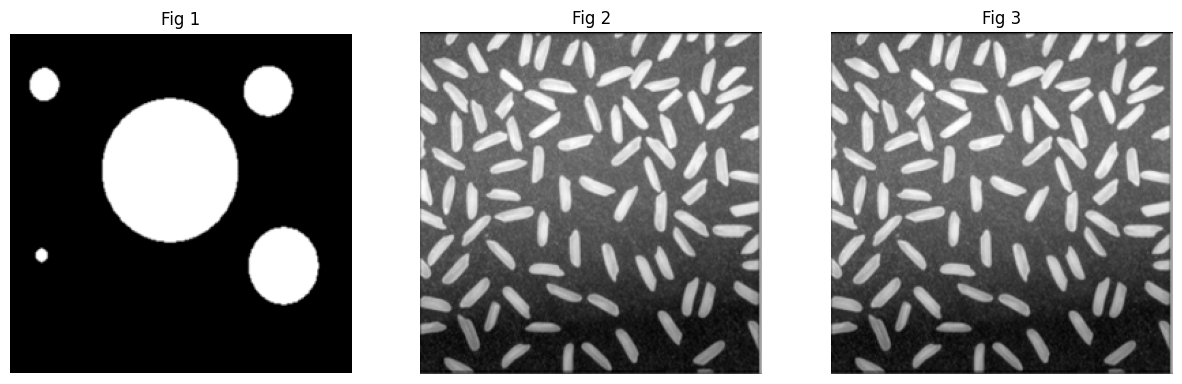

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(fig1, cmap='gray')
plt.title("Fig 1")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(fig2, cmap='gray')
plt.title("Fig 2")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(fig3, cmap='gray')
plt.title("Fig 3")
plt.axis('off')

plt.show()

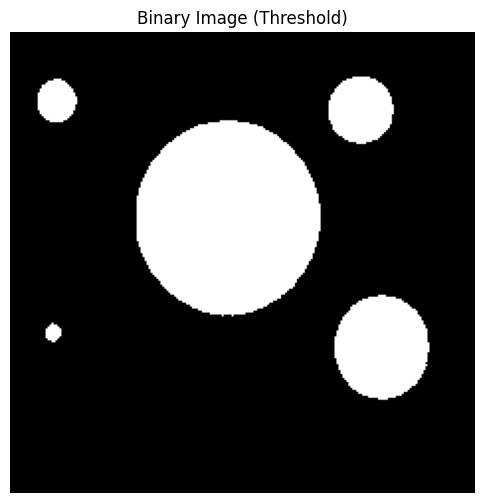

In [ ]:
threshold_value = 150

_, binary_image = cv2.threshold(
    fig1,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image (Threshold)")
plt.axis('off')
plt.show()

In [ ]:
# Threshold Fig-1
_, binary1 = cv2.threshold(fig1, 127, 255, cv2.THRESH_BINARY)

# Structuring Elements
kernel4 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
kernel8 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Boundary Extraction
eroded4 = cv2.erode(binary1, kernel4)
boundary4 = binary1 - eroded4

eroded8 = cv2.erode(binary1, kernel8)
boundary8 = binary1 - eroded8

perimeter4 = np.count_nonzero(boundary4)
perimeter8 = np.count_nonzero(boundary8)

print("Question 1")
print("Perimeter using 4-connectivity =", perimeter4)
print("Perimeter using 8-connectivity =", perimeter8)

Question 1
Perimeter using 4-connectivity = 590
Perimeter using 8-connectivity = 827


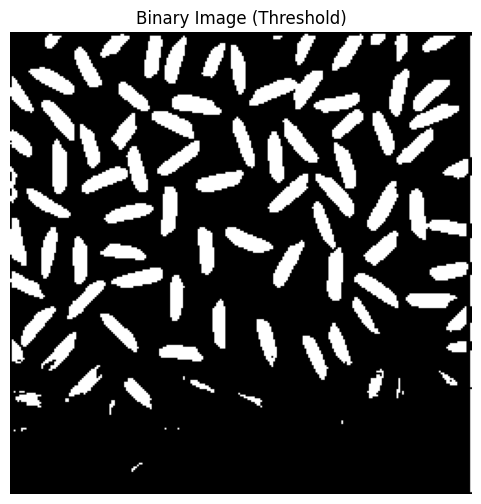

In [ ]:
threshold_value = 150

_, binary_image = cv2.threshold(
    fig2,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image (Threshold)")
plt.axis('off')
plt.show()


In [ ]:
structure4 = ndimage.generate_binary_structure(2, 1)
labeled4, num_objects4 = ndimage.label(binary_image, structure4)

# 8-connected
structure8 = ndimage.generate_binary_structure(2, 2)
labeled8, num_objects8 = ndimage.label(binary_image, structure8)

print("\nQuestion 3")
print("Number of objects (4-connected) =", num_objects4)
print("Number of objects (8-connected) =", num_objects8)


Question 3
Number of objects (4-connected) = 109
Number of objects (8-connected) = 104


In [ ]:
p1 = (100, 100)
p2 = (300, 250)

distance = np.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)

print("\nQuestion 4")
print("Point 1 =", p1)
print("Point 2 =", p2)
print("Euclidean Distance =", distance)


Question 4
Point 1 = (100, 100)
Point 2 = (300, 250)
Euclidean Distance = 250.0



Question 5 Completed


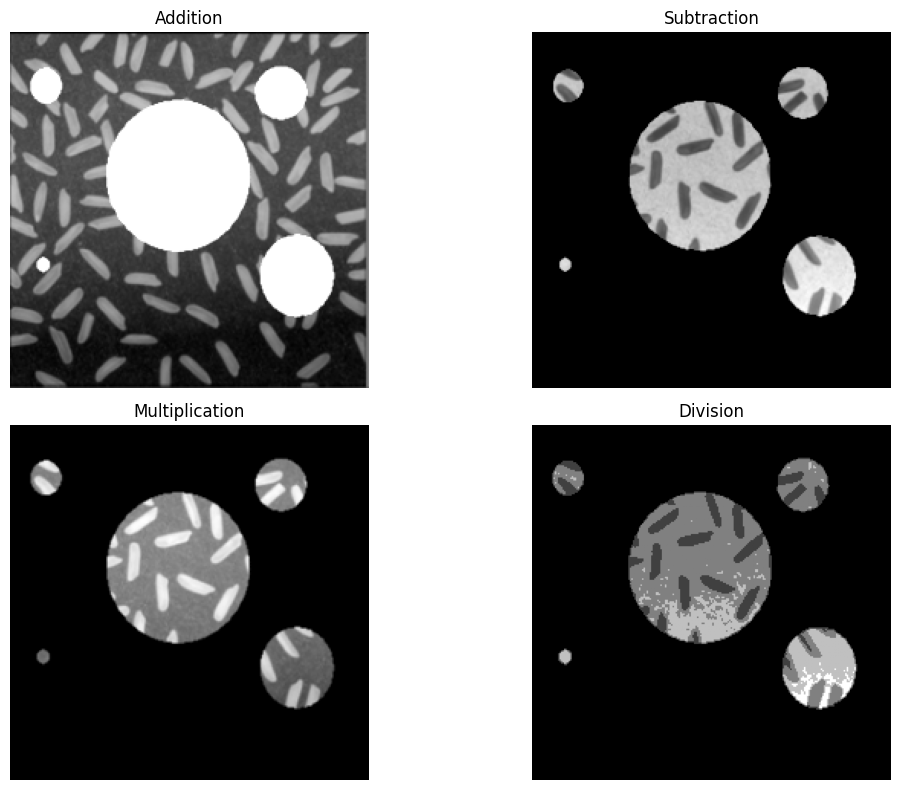

In [ ]:
fig2_resized = cv2.resize(fig2, (fig1.shape[1], fig1.shape[0]))

addition = cv2.add(fig1, fig2_resized)
subtraction = cv2.subtract(fig1, fig2_resized)
multiplication = cv2.multiply(fig1, fig2_resized, scale=1/255)
division = cv2.divide(fig1, fig2_resized + 1)

print("\nQuestion 5 Completed")

titles = [
    "Addition",
    "Subtraction",
    "Multiplication",
    "Division"
]

images = [
    addition,
    subtraction,
    multiplication,
    division
]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


Question 6 Completed


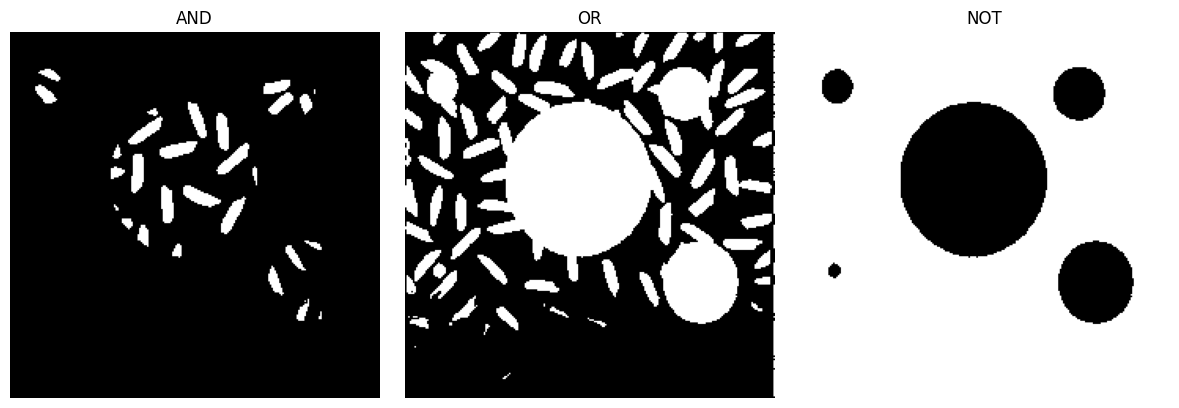

In [ ]:
_, b1 = cv2.threshold(fig1, 150, 255, cv2.THRESH_BINARY)
_, b2 = cv2.threshold(fig2_resized, 150, 255, cv2.THRESH_BINARY)

and_img = cv2.bitwise_and(b1, b2)
or_img = cv2.bitwise_or(b1, b2)
not_img = cv2.bitwise_not(b1)

print("\nQuestion 6 Completed")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(and_img, cmap='gray')
plt.title("AND")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(or_img, cmap='gray')
plt.title("OR")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(not_img, cmap='gray')
plt.title("NOT")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')